<a href="https://colab.research.google.com/github/marcinwolter/PPSS_2026/blob/main/ROOT_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ROOT PPSS Exercise**

Wall time - 4 minutes

### Solution for the problem: Exercise 2: ROOT - Event Selection

In [ ]:
! pip install ROOT

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.9/247.9 MB 3.5 MB/s eta 0:00:00


In [ ]:
! rm -f *.root
! rm -f *.root.*
! rm -f *.pdf

In [ ]:
! wget --no-check-certificate https://ppss.ifj.edu.pl/materials_2019/MC_resonance_search_signal.root
! wget --no-check-certificate https://ppss.ifj.edu.pl/materials_2019/MC_resonance_search_background_small.root
# ! wget --no-check-certificate https://ppss.ifj.edu.pl/materials_2019/MC_resonance_search_background.root

! wget --no-check-certificate https://ppss.ifj.edu.pl/materials_2019/data.root

--2026-07-03 11:47:24--  https://ppss.ifj.edu.pl/materials_2019/MC_resonance_search_signal.root
Resolving ppss.ifj.edu.pl (ppss.ifj.edu.pl)... 192.86.14.59
Connecting to ppss.ifj.edu.pl (ppss.ifj.edu.pl)|192.86.14.59|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 7199436 (6.9M)
Saving to: ‘MC_resonance_search_signal.root’

MC_resonance_search 100%[===================>]   6.87M  5.42MB/s    in 1.3s    

2026-07-03 11:47:26 (5.42 MB/s) - ‘MC_resonance_search_signal.root’ saved [7199436/7199436]

--2026-07-03 11:47:26--  https://ppss.ifj.edu.pl/materials_2019/MC_resonance_search_background_small.root
Resolving ppss.ifj.edu.pl (ppss.ifj.edu.pl)... 192.86.14.59
Connecting to ppss.ifj.edu.pl (ppss.ifj.edu.pl)|192.86.14.59|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 30555952 (29M)
Saving to: ‘MC_resonance_search_background_small.root’



# Define the analysis function

In [ ]:
import ROOT
import math

def analyze(output_file, input_files):

    chain = ROOT.TChain("ntuple")

    for f in input_files:
        chain.Add(f)

    output = ROOT.TFile(output_file, "RECREATE")

    h_x = ROOT.TH1F("h_x", "", 100, -1e-4, 1e-4)
    h_x_electron = ROOT.TH1F("h_x_electron", "", 100, -1e-4, 1e-4)
    h_x_positron = ROOT.TH1F("h_x_positron", "", 100, -1e-4, 1e-4)

    h_x_y = ROOT.TH2F("h_x_y", "", 100, -1e-4, 1e-4,
                                   100, -1e-4, 1e-4)

    h_mu_like_muon = ROOT.TH1F(
        "h_mu_like_muon",
        "mu like for muons",
        100, 0., 1.
    )

    h_mu_like_notmuon = ROOT.TH1F(
        "h_mu_like_notmuon",
        "mu like for other particles",
        100, 0., 1.
    )

    h_pT_pos = ROOT.TH1F(
        "h_pT_pos",
        "transverse momentum of mu+",
        100, 0., 50.
    )

    h_pT_neg = ROOT.TH1F(
        "h_pT_neg",
        "transverse momentum of mu-",
        100, 0., 50.
    )

    h_z = ROOT.TH1F(
        "h_z",
        "z-distance of muon vertex",
        100, -0.15, 0.15
    )

    h_phi_pos_vs_phi_neg = ROOT.TH2F(
        "h_phi_pos_vs_phi_neg",
        "correlation between angular momentum of muons",
        30, -3., 3.,
        30, -3., 3.
    )

    h_phi_diff = ROOT.TH1F(
        "h_phi_diff",
        "difference of muon angular momentum",
        50, 0., 6.5
    )

    h_m = ROOT.TH1F(
        "h_m",
        "invariant mass no cut",
        100, 0., 50.
    )

    h_m_cut1 = ROOT.TH1F(
        "h_m_cut1",
        "invariant mass after pT cut",
        100, 0., 50.
    )

    h_m_cut2 = ROOT.TH1F(
        "h_m_cut2",
        "invariant mass after pT and z cut",
        100, 0., 50.
    )

    h_m_cut3 = ROOT.TH1F(
        "h_m_cut3",
        "invariant mass after pT, z and phi cut",
        100, 0., 50.
    )

    nentries = chain.GetEntries()
    print(f"Number of events: {nentries}")

    for ievent, event in enumerate(chain):

        if ievent % 10000 == 0:
            print(f"{ievent}/{nentries}")

        v_mu_pos = ROOT.TLorentzVector()
        v_mu_neg = ROOT.TLorentzVector()

        particle_number_mu_pos = -1
        particle_number_mu_neg = -1

        nparticles = len(event.id)

        for particle in range(nparticles):

            pid = event.id[particle]

            h_x.Fill(event.x[particle])
            h_x_y.Fill(event.x[particle],
                       event.y[particle])

            if pid == 11:
                h_x_electron.Fill(event.x[particle])

            if pid == -11:
                h_x_positron.Fill(event.x[particle])

            if abs(pid) == 13:
                h_mu_like_muon.Fill(
                    event.mu_like[particle]
                )
            else:
                h_mu_like_notmuon.Fill(
                    event.mu_like[particle]
                )

            if event.mu_like[particle] > 0.7:

                v = ROOT.TLorentzVector()
                v.SetPxPyPzE(
                    event.px[particle],
                    event.py[particle],
                    event.pz[particle],
                    event.e[particle]
                )

                if abs(event.charge[particle] - 1.) < 1e-6:

                    if v.Pt() > v_mu_neg.Pt():
                        v_mu_neg = ROOT.TLorentzVector(v)
                        particle_number_mu_neg = particle

                elif abs(event.charge[particle] + 1.) < 1e-6:

                    if v.Pt() > v_mu_pos.Pt():
                        v_mu_pos = ROOT.TLorentzVector(v)
                        particle_number_mu_pos = particle

        v_sum = v_mu_pos + v_mu_neg

        h_m.Fill(v_sum.M())

        if particle_number_mu_neg == -1:
            continue

        if particle_number_mu_pos == -1:
            continue

        h_pT_pos.Fill(v_mu_pos.Pt())
        h_pT_neg.Fill(v_mu_neg.Pt())

        h_phi_pos_vs_phi_neg.Fill(
            v_mu_neg.Phi(),
            v_mu_pos.Phi()
        )

        if (
            7.0 < v_mu_neg.Pt() < 14.0 and
            7.0 < v_mu_pos.Pt() < 14.0
        ):

            h_m_cut1.Fill(v_sum.M())

            dz = (
                event.z[particle_number_mu_neg]
                - event.z[particle_number_mu_pos]
            )

            h_z.Fill(dz)

            if abs(dz) < 0.015:

                h_m_cut2.Fill(v_sum.M())

                dphi = abs(
                    v_mu_neg.Phi()
                    - v_mu_pos.Phi()
                )

                h_phi_diff.Fill(dphi)

                if 2.3 < dphi < 4.2:
                    h_m_cut3.Fill(v_sum.M())

    output.Write()
    output.Close()

    print("[ DONE ]")

/usr/local/lib/python3.12/dist-packages/ROOT/__init__.py:222: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(


# Processing data

In [ ]:
analyze("out_dat.root", ["data.root"])

Number of events: 45450
0/45450
10000/45450
20000/45450
30000/45450
40000/45450
[ DONE ]


In [ ]:
analyze("out_sig.root", ["MC_resonance_search_signal.root"])

Number of events: 10000
0/10000
[ DONE ]


In [ ]:

analyze("out_bkg.root", ["MC_resonance_search_background_small.root"])
# analyze("out_bkg.root", ["MC_resonance_search_background.root"])

Number of events: 29900
0/29900
10000/29900
20000/29900
[ DONE ]


# Plotting results and producing pdf file

In [ ]:
import ROOT
from IPython.display import Image, display

# Open files
f1 = ROOT.TFile.Open("out_dat.root")
f2 = ROOT.TFile.Open("out_sig.root")
f3 = ROOT.TFile.Open("out_bkg.root")

# Retrieve histograms
h_x_1 = f1.Get("h_x")
h_x_2 = f2.Get("h_x")
h_x_3 = f3.Get("h_x")

# Set colors
h_x_1.SetLineColor(ROOT.kBlack)
h_x_2.SetLineColor(ROOT.kRed)
h_x_3.SetLineColor(ROOT.kBlue)

# Signal-only histograms
h_x_electron = f2.Get("h_x_electron")
h_x_positron = f2.Get("h_x_positron")

h_x_electron.SetLineColor(ROOT.kBlack)
h_x_positron.SetLineColor(ROOT.kRed)

h_x_electron.Scale(1.0 / h_x_electron.GetEntries())
h_x_positron.Scale(1.0 / h_x_positron.GetEntries())

h_x_y_1 = f1.Get("h_x_y")
h_x_y_2 = f2.Get("h_x_y")
h_x_y_3 = f3.Get("h_x_y")

ROOT.gStyle.SetOptStat(0)

c = ROOT.TCanvas("c", "", 800, 600)

# Open multipage PDF
c.Print("plots.pdf[")


Info in <TCanvas::Print>: pdf file plots.pdf has been created


Info in <TCanvas::Print>: Current canvas added to pdf file plots.pdf


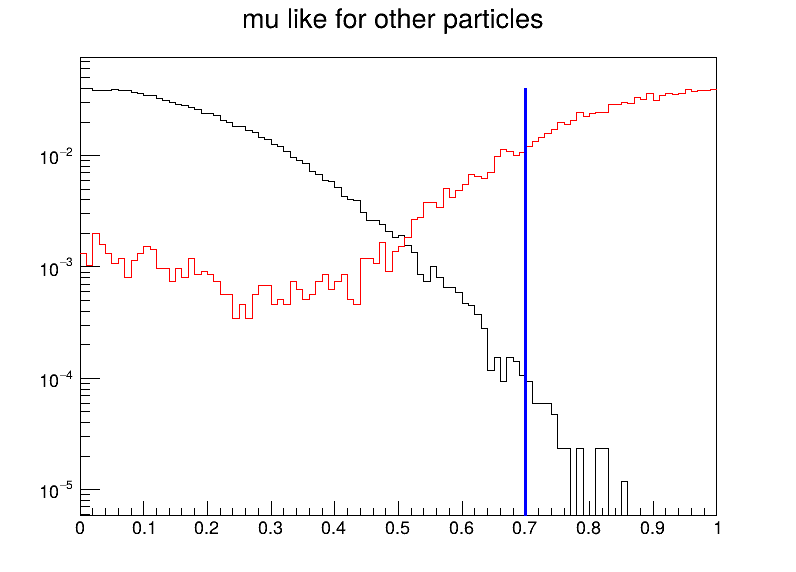

Info in <TCanvas::Print>: png file temp_plot.png has been created


In [ ]:

# --------------------------------------------------
# mu_like distributions
# --------------------------------------------------

h_mu_like_notmuon = f2.Get("h_mu_like_notmuon")
h_mu_like_muon = f2.Get("h_mu_like_muon")

ROOT.gPad.SetLogy(True)

h_mu_like_notmuon.Scale(
    1.0 / h_mu_like_notmuon.GetEntries()
)

h_mu_like_muon.Scale(
    1.0 / h_mu_like_muon.GetEntries()
)

h_mu_like_notmuon.SetLineColor(ROOT.kBlack)
h_mu_like_muon.SetLineColor(ROOT.kRed)

h_mu_like_notmuon.Draw("hist")
h_mu_like_muon.Draw("hist same")

ymax = h_mu_like_notmuon.GetMaximum()
ymin = h_mu_like_notmuon.GetMinimum()

cut_line = ROOT.TLine(0.7, ymin, 0.7, ymax)
cut_line.SetLineColor(ROOT.kBlue)
cut_line.SetLineWidth(3)
cut_line.Draw()

c.Print("plots.pdf")

# Save the exact same canvas to a temporary PNG file
c.Print("temp_plot.png")

# Display the PNG inline inside your Colab notebook
display(Image(filename="temp_plot.png"))

Info in <TCanvas::Print>: Current canvas added to pdf file plots.pdf
Info in <TCanvas::Print>: png file temp_plot.png has been created


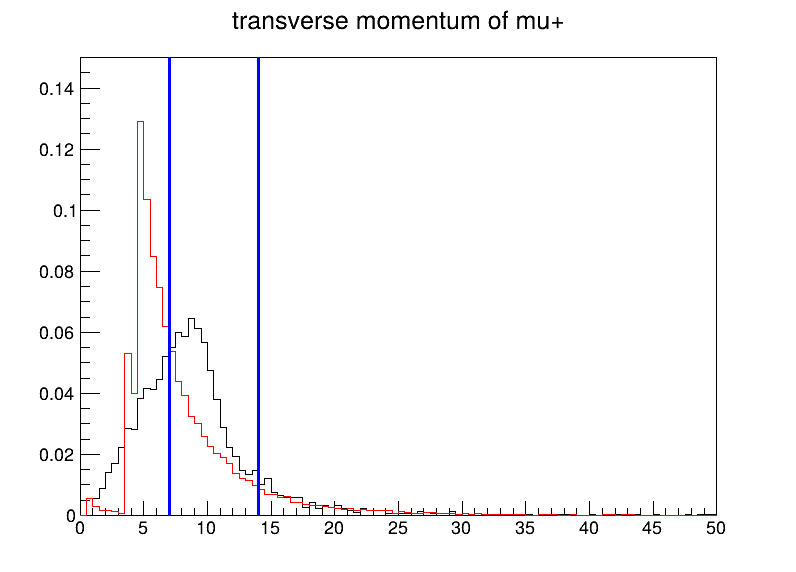

In [ ]:

# --------------------------------------------------
# pT(mu+)
# --------------------------------------------------

c.Clear()

h_pT_pos_sig = f2.Get("h_pT_pos")
h_pT_pos_bkg = f3.Get("h_pT_pos")

ROOT.gPad.SetLogy(False)

h_pT_pos_sig.Scale(
    1.0 / h_pT_pos_sig.GetEntries()
)

h_pT_pos_bkg.Scale(
    1.0 / h_pT_pos_bkg.GetEntries()
)

h_pT_pos_sig.SetLineColor(ROOT.kBlack)
h_pT_pos_bkg.SetLineColor(ROOT.kRed)

h_pT_pos_sig.SetMaximum(0.15)

h_pT_pos_sig.Draw("hist")
h_pT_pos_bkg.Draw("hist same")

ymax = h_pT_pos_sig.GetMaximum()
ymin = h_pT_pos_sig.GetMinimum()

l2 = ROOT.TLine(7., ymin, 7., ymax)
l3 = ROOT.TLine(14., ymin, 14., ymax)

for l in (l2, l3):
    l.SetLineColor(ROOT.kBlue)
    l.SetLineWidth(3)
    l.Draw()

c.Print("plots.pdf")

# Save the exact same canvas to a temporary PNG file
c.Print("temp_plot.png")

# Display the PNG inline inside your Colab notebook
display(Image(filename="temp_plot.png"))

Info in <TCanvas::Print>: Current canvas added to pdf file plots.pdf
Info in <TCanvas::Print>: png file temp_plot.png has been created


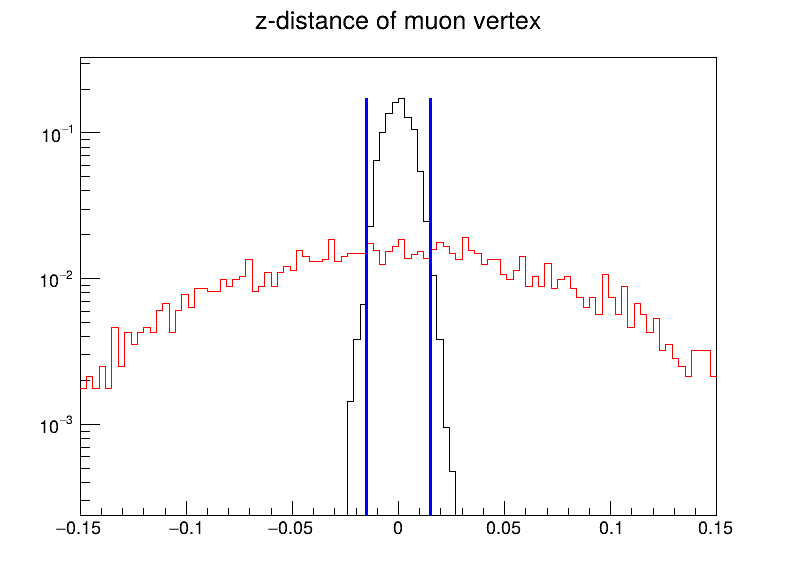

In [ ]:

# --------------------------------------------------
# z-distance
# --------------------------------------------------

c.Clear()

h_z_sig = f2.Get("h_z")
h_z_bkg = f3.Get("h_z")

ROOT.gPad.SetLogy(True)

h_z_sig.Scale(
    1.0 / h_z_sig.GetEntries()
)

h_z_bkg.Scale(
    1.0 / h_z_bkg.GetEntries()
)

h_z_sig.SetLineColor(ROOT.kBlack)
h_z_bkg.SetLineColor(ROOT.kRed)

h_z_sig.Draw("hist")
h_z_bkg.Draw("hist same")

ymax = h_z_sig.GetMaximum()
ymin = h_z_sig.GetMinimum()

l4 = ROOT.TLine(0.015, ymin, 0.015, ymax)
l5 = ROOT.TLine(-0.015, ymin, -0.015, ymax)

for l in (l4, l5):
    l.SetLineColor(ROOT.kBlue)
    l.SetLineWidth(3)
    l.Draw()

c.Print("plots.pdf")

# Save the exact same canvas to a temporary PNG file
c.Print("temp_plot.png")

# Display the PNG inline inside your Colab notebook
display(Image(filename="temp_plot.png"))

Info in <TCanvas::Print>: Current canvas added to pdf file plots.pdf
Info in <TCanvas::Print>: png file temp_plot.png has been created


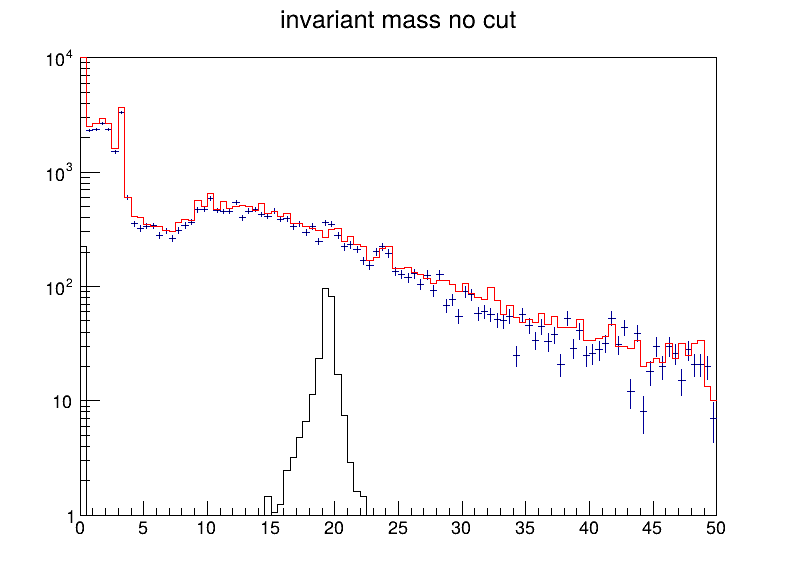

In [ ]:

# --------------------------------------------------
# Invariant mass
# --------------------------------------------------

h_m_data = f1.Get("h_m")
h_m_sig = f2.Get("h_m")
h_m_bkg = f3.Get("h_m")

MC_sigma_sig = 5.0
MC_sigma_bkg = 500.0
L = 100.0

n_sig = h_m_sig.GetEntries()
n_bkg = h_m_bkg.GetEntries()

h_m_sig.Scale(MC_sigma_sig * L / n_sig)
h_m_bkg.Scale(MC_sigma_bkg * L / n_bkg)

ROOT.gPad.SetLogy(True)

h_m_data.SetMaximum(1e4)
h_m_data.SetMinimum(1.)

h_m_sig.SetLineColor(ROOT.kBlack)
h_m_bkg.SetLineColor(ROOT.kRed)

h_m_data.Draw("PE")
h_m_sig.Draw("hist same")
h_m_bkg.Draw("hist same")

c.Print("plots.pdf")

# Save the exact same canvas to a temporary PNG file
c.Print("temp_plot.png")

# Display the PNG inline inside your Colab notebook
display(Image(filename="temp_plot.png"))

Info in <TCanvas::Print>: Current canvas added to pdf file plots.pdf


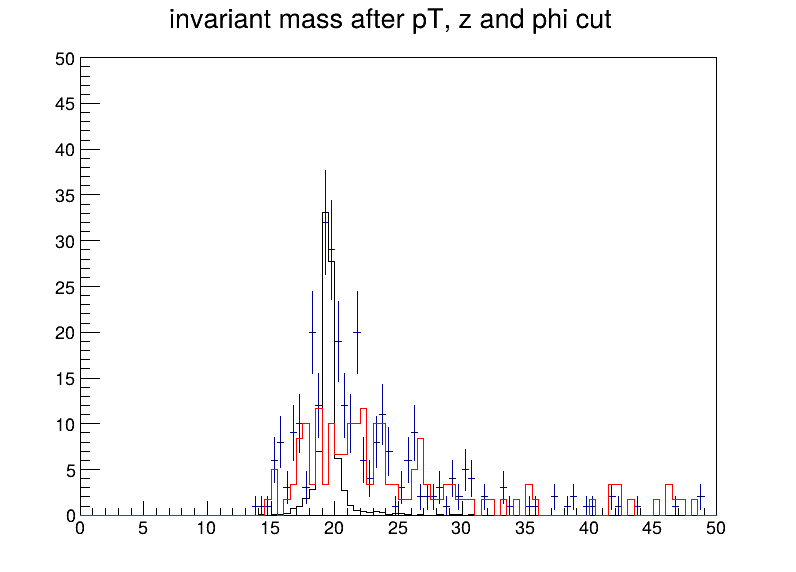

Info in <TCanvas::Print>: png file temp_plot.png has been created


In [ ]:

# --------------------------------------------------
# Final selection
# --------------------------------------------------

h_m_cut3_data = f1.Get("h_m_cut3")
h_m_cut3_sig = f2.Get("h_m_cut3")
h_m_cut3_bkg = f3.Get("h_m_cut3")

h_m_cut3_sig.Scale(MC_sigma_sig * L / n_sig)
h_m_cut3_bkg.Scale(MC_sigma_bkg * L / n_bkg)

-h_m_cut3_bkg.SetLineColor(ROOT.kRed)

c.Clear()
ROOT.gPad.SetLogy(False)

h_m_cut3_data.SetMaximum(50.)
h_m_cut3_data.SetMinimum(0.)

h_m_cut3_data.Draw("PE")
h_m_cut3_sig.Draw("hist same")
h_m_cut3_bkg.Draw("hist same")

c.Print("plots.pdf")

# Save the exact same canvas to a temporary PNG file
c.Print("temp_plot.png")

# Display the PNG inline inside your Colab notebook
display(Image(filename="temp_plot.png"))